In [1]:
%%shell
git clone https://github.com/ClementPinard/SfmLearner-Pytorch
cd SfmLearner-Pytorch
pip install -qr requirements.txt
mkdir -p pretrained
gdown --fuzzy https://drive.google.com/file/d/1o-cKKbq8jGvjaiEKuKWDjEMmI5Y4PN9K/view?usp=sharing -O pretrained/exp_pose_model_best.pth.tar
gdown --fuzzy https://drive.google.com/file/d/1SOyTw_XDzirdf-tSz_TV7HjAG4wWB3nr/view?usp=sharing -O pretrained/dispnet_model_best.pth.tar
gdown --fuzzy https://drive.google.com/file/d/1AjRNHg-OuN6K9ygzsikRxqcRb5J_i0dv/view?usp=sharing -O odometry.zip
unzip odometry.zip > /dev/null

Cloning into 'SfmLearner-Pytorch'...
remote: Enumerating objects: 556, done.
remote: Total 556 (delta 0), reused 0 (delta 0), pack-reused 556
Receiving objects: 100% (556/556), 6.75 MiB | 21.61 MiB/s, done.
Resolving deltas: 100% (342/342), done.
     |████████████████████████████████| 125 kB 48.4 MB/s 
Downloading...
From: https://drive.google.com/uc?id=1o-cKKbq8jGvjaiEKuKWDjEMmI5Y4PN9K
To: /content/SfmLearner-Pytorch/pretrained/exp_pose_model_best.pth.tar
100% 6.40M/6.40M [00:00<00:00, 14.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1SOyTw_XDzirdf-tSz_TV7HjAG4wWB3nr
To: /content/SfmLearner-Pytorch/pretrained/dispnet_model_best.pth.tar
100% 126M/126M [00:02<00:00, 49.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1AjRNHg-OuN6K9ygzsikRxqcRb5J_i0dv
To: /content/SfmLearner-Pytorch/odometry.zip
100% 549M/549M [00:09<00:00, 54.9MB/s]


In [3]:
%%shell
cd SfmLearner-Pytorch
# mkdir -p odometry/output/01_chair
# python test_pose.py pretrained/exp_pose_model_best.pth.tar --dataset-dir odometry --sequences 01_chair --output-dir odometry/output/01_chair
mkdir -p odometry/output/02_screen
python test_pose.py pretrained/exp_pose_model_best.pth.tar --dataset-dir odometry --sequences 02_screen --output-dir odometry/output/02_screen

getting test metadata for theses sequences : {Path('odometry/sequences/02_screen')}
100% 1/1 [00:00<00:00, 148.28it/s]
300 snippets to test
 99% 296/300 [06:22<00:05,  1.29s/it]

Results
	        ATE,         RE
mean 	     0.8306,     0.0928
std 	     4.3911,     0.1380


In [4]:
import numpy as np

predictions = np.load("SfmLearner-Pytorch/odometry/output/02_screen/predictions.npy")

for i in range(1, len(predictions)):
    r = predictions[i - 1, 1]
    predictions[i] = r[:, :3] @ predictions[i]
    predictions[i, :, :, -1] = predictions[i, :, :, -1] + r[:, -1]

predictions.shape

(300, 5, 3, 4)

In [13]:
import numpy as np
import plotly.express as px

path = []
for i in range(predictions.shape[1]):
    x = predictions[0, i, 0, 3]
    y = predictions[0, i, 1, 3]
    z = predictions[0, i, 2, 3]
    path = np.append(path, [x, y, z])

for i in range(1, predictions.shape[0]):
    x = predictions[i, -1, 0, 3]
    y = predictions[i, -1, 1, 3]
    z = predictions[i, -1, 2, 3]
    path = np.append(path, [x, y, z])

path = path.reshape(-1, 3)
print(path.shape)

fig = px.scatter_3d(x=path[..., 0], y=path[..., 1], z=path[..., 2], range_x=[-4, 2], range_y=[-4, 2], range_z=[0, 6])
fig.show()

(304, 3)


In [14]:
%%shell
cd SfmLearner-Pytorch
# mkdir -p odometry/output/01_chair/image_2
# python run_inference.py --pretrained pretrained/dispnet_model_best.pth.tar --dataset-dir odometry/sequences/01_chair/image_2 --output-dir odometry/output/01_chair/image_2 --output-disp --output-depth --img-width 416 --img-height 234
mkdir -p odometry/output/02_screen/image_2
python run_inference.py --pretrained pretrained/dispnet_model_best.pth.tar --dataset-dir odometry/sequences/02_screen/image_2 --output-dir odometry/output/02_screen/image_2 --output-disp --output-depth --img-width 416 --img-height 234

300 files to test
100% 300/300 [02:49<00:00,  1.77it/s]


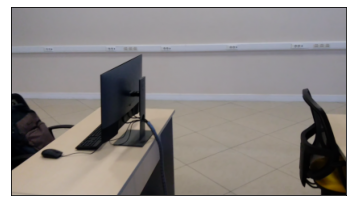

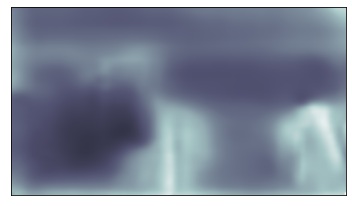

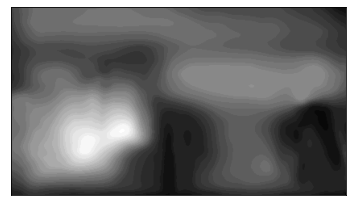

In [27]:
from skimage import io
from skimage.transform import resize
import matplotlib.pyplot as plt

plt.imshow(resize(io.imread("SfmLearner-Pytorch/odometry/sequences/02_screen/image_2/frame_015.png"), (234, 416)))
plt.xticks([])
plt.yticks([])
plt.show()
plt.imshow(io.imread("SfmLearner-Pytorch/odometry/output/02_screen/image_2/frame_015_disp.png"))
plt.xticks([])
plt.yticks([])
plt.show()
plt.imshow(io.imread("SfmLearner-Pytorch/odometry/output/02_screen/image_2/frame_015_depth.png")[..., 1], cmap="gray")
plt.xticks([])
plt.yticks([])
plt.show()